In [7]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

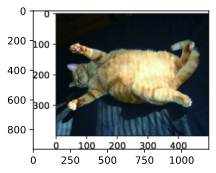

In [8]:
d2l.set_figsize()
# 设置 Matplotlib 绘图的默认尺寸（D2L 封装的便捷函数），避免图像过大 / 过小。
# 默认值：通常默认尺寸为 (3.5, 2.5)，可传入参数自定义（如 d2l.set_figsize((5, 4))）。

img = d2l.Image.open('./13-0a.tif')
# d2l.Image：D2L 封装的 PIL（Python Imaging Library）Image 类（等价于 from PIL import Image 后调用 Image）；
# open('./13-0a.tif')：打开当前目录下名为 13-0a.tif 的 TIFF 格式图像文件，返回一个 PIL Image 对象；
# 赋值给 img：后续可对该图像对象进行增强、显示等操作。

d2l.plt.imshow(img);
# d2l.plt：D2L 封装的 Matplotlib pyplot 模块（等价于 import matplotlib.pyplot as plt 后调用 plt）；
# imshow(img)：将 PIL Image 对象 img 显示出来；
# 末尾的 ;：Jupyter 环境中抑制额外的输出（如 <matplotlib.image.AxesImage object at 0x...>），仅显示图像。


In [11]:
def apply(img,aug,num_rows=2,num_cols=4,scale=1.5):
        #     img：原始 PIL Image 对象（待增强的图像）；
        # aug：图像增强函数 / 变换（如 torchvision.transforms.RandomHorizontalFlip()）；
        # num_rows=2：展示图像的行数（默认 2 行）；
        # num_cols=4：展示图像的列数（默认 4 列）；
        # scale=1.5：图像显示的缩放比例（默认 1.5 倍，使图像更大更清晰）。
    Y = [aug(img) for _ in range(num_rows*num_cols)]
        #     num_rows*num_cols：计算总展示图像数（默认 2×4=8 张）；
        # aug(img)：对原始图像 img 应用增强变换 aug，生成一张增强后的图像；
        # 列表推导式：循环 num_rows*num_cols 次，每次生成一张增强图像，最终得到包含所有增强图像的列表 Y。
    d2l.show_images(Y,num_rows,num_cols,scale=scale)
        #     作用：调用 D2L 封装的 show_images 函数，将增强后的图像列表 Y 按指定行列数和缩放比例展示为网格布局。
        # 逻辑：自动将列表 Y 中的图像按 num_rows 行、num_cols 列排列，scale 控制整体显示尺寸，避免图像重叠 / 过小。

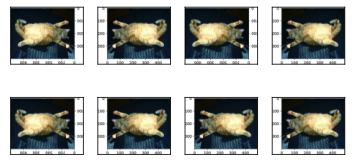

In [12]:
#翻转和裁剪
#水平反转
apply(img,torchvision.transforms.RandomHorizontalFlip())

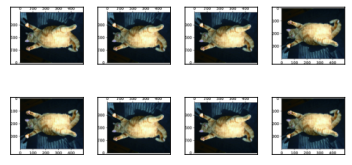

In [13]:
apply(img,torchvision.transforms.RandomVerticalFlip())
#垂直翻转

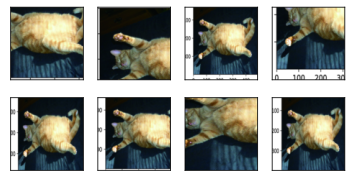

In [14]:
#裁剪
shape_aug = torchvision.transforms.RandomResizedCrop(
    (200,200),scale=(0.1,1),ratio=(0.5,2))
apply(img,shape_aug)

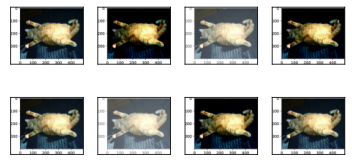

In [18]:
#改变颜色
apply(img,torchvision.transforms.ColorJitter(
    brightness=0.5,contrast=0,saturation=0,hue=0))
#亮度改变为原始图片的0.5-1.5

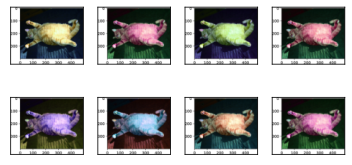

In [19]:
#改变色调
apply(img,torchvision.transforms.ColorJitter(
    brightness=0,contrast=0,saturation=0,hue=0.5))

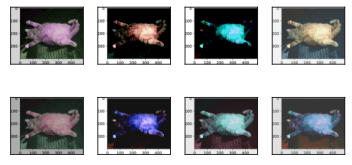

In [20]:
color_aug = torchvision.transforms.ColorJitter(
    brightness=0.5,contrast=0.5,saturation=0.5,hue=0.5)
apply(img,color_aug)

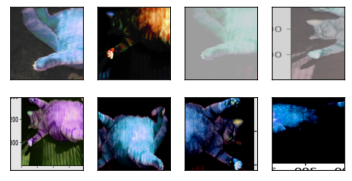

In [21]:
#结合多种图像增广的方法
augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),color_aug,shape_aug])
apply(img,augs)